# Inits

In [ ]:
import pandas as pd
import numpy as np
from scipy.integrate import trapz
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import os

os.chdir("..")

# Structuring Results Dataframe

In [11]:
df = pd.read_excel("scoring_model/data/Worm Counting updated.xlsx", sheet_name = "scores")

def calc_auc(group):
    time = group["time"]
    prop = group["prop_alive"]
    return trapz(prop, time)
    
auc_df = df.groupby("sequence").apply(calc_auc).reset_index(name = "auc")

control_auc = auc_df[auc_df["sequence"] == "control"]["auc"].values
auc_df = auc_df[auc_df["sequence"] != "control"]
auc_df["observer"] = auc_df["sequence"].apply(lambda x: "maddy" if x < 12 else "emma")
control_emma = control_auc * np.median(auc_df[auc_df["observer"] == "emma"]["auc"]) / np.median(auc_df[auc_df["observer"] == "maddy"]["auc"])

auc_df["corrected_auc"] = auc_df.apply(lambda row: float(row["auc"] / control_auc if row["observer"] == "maddy" else row["auc"] / control_emma) - 1, axis = 1)

C:\Users\Jackson\AppData\Local\Temp\ipykernel_20584\3575671071.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  auc_df["corrected_auc"] = auc_df.apply(lambda row: float(row["auc"] / control_auc if row["observer"] == "maddy" else row["auc"] / control_emma) - 1, axis = 1)


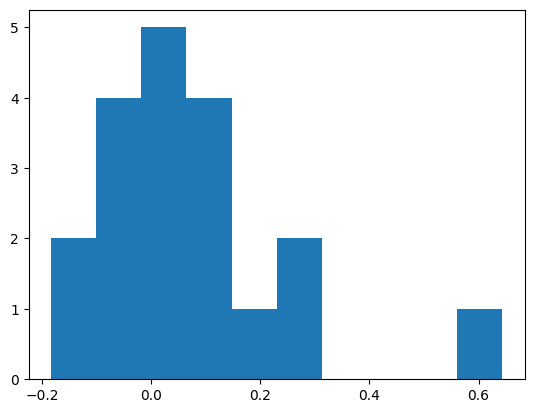

In [3]:
plt.figure()
plt.hist(auc_df["corrected_auc"])
plt.show()

# Getting correct format for input

c:\Users\Jackson\Documents\ecc\scoring_model\structuring_data.py:209: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_len = df["length"].agg(max)


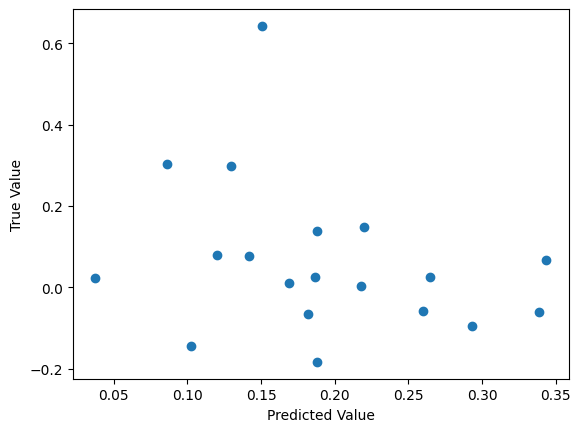

In [10]:
from structuring_data import structure_dataframe
from scoring_model import score_sgRNAs

input_df = pd.read_excel("scoring_model/data/Worm Counting updated.xlsx", sheet_name = "sgRNAs")
structured_df = structure_dataframe(input_df.drop(columns = "seq_ID"), dir = "../genomes/c_elegans_n2")

test_score = score_sgRNAs(structured_df, -1, "scoring_model/models/LGBM.pk1")

auc_df["score"] = test_score

plt.figure()
plt.scatter(auc_df["score"], auc_df["corrected_auc"])
plt.xlabel("Predicted Value")
plt.ylabel("True Value")
plt.show()

# Retraining model

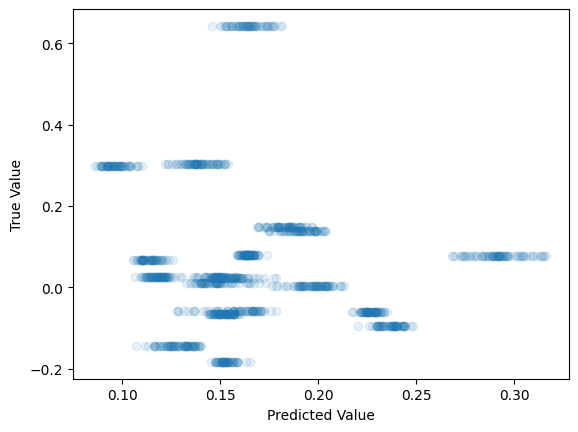

-0.44899495124346167


In [12]:
import joblib
import copy

# with open("scoring_model/models/LGBM.pk1", "rb") as file:
#     model = pickle.load(file)

model = joblib.load("scoring_model/models/RF.joblib")

n_bootstraps = 300
all_preds = []
all_tests = []

# model.booster_.save_model("test.txt")

for i in range(n_bootstraps):
    X_train, X_test, y_train, y_test = train_test_split(structured_df.drop(columns = ["PAMloc", "strand", "sequence", "struct"]), 
                                                        auc_df["corrected_auc"], 
                                                        test_size = 0.2, 
                                                        random_state = i)

    mod2 = copy.deepcopy(model)
    mod2.warm_start = True
    mod2.n_estimators += 100
    
    mod2.fit(X_train, y_train)

    preds = mod2.predict(X_test)
    
    all_preds.extend(preds)
    all_tests.extend(y_test)

plt.figure()
plt.scatter(all_preds, all_tests, alpha = 0.1)
plt.xlabel("Predicted Value")
plt.ylabel("True Value")
plt.show()

print(r2_score(all_tests, all_preds))